In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


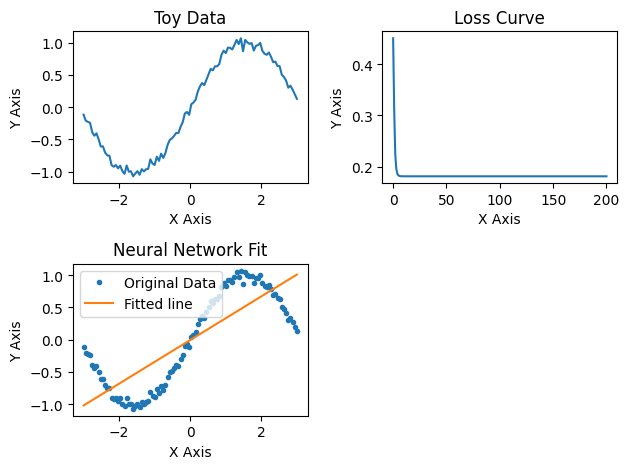

In [2]:

# TODO: Generate the toy data
x = np.linspace(-3, 3, 100)

y = np.sin(x) + np.random.normal(0, 0.05, size=x.shape)


#   Plot it.

plt.subplot(2, 2, 1)
plt.plot(x, y)
plt.xlabel("X Axis")
plt.ylabel("Y Axis")
plt.title("Toy Data")

# TODO: Initialise w and b to small random values.

w = np.random.rand() * 0.1
b = np.random.rand() * 0.1

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:

y_hat = w * x + b
lr = 0.05
losses = []

loss  = np.mean((y_hat - y) ** 2)               # MSE
dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
db    = np.mean(2 * (y_hat - y))                # dLoss/db
w    -= lr * dw
b    -= lr * db
losses.append(loss)

#   Record the loss at every step.
for i in range(200):
  y_hat = w * x + b
  lr = 0.07
  loss  = np.mean((y_hat - y) ** 2)
  dw    = np.mean(2 * (y_hat - y) * x)
  db    = np.mean(2 * (y_hat - y))
  w    -= lr * dw
  b    -= lr * db
  losses.append(loss)


# TODO: Plot

#  (a) the loss curve over the 200 steps, and
# plt.plot(x, y_hat)
plt.subplot(2, 2, 2)
plt.plot(losses)
plt.xlabel("X Axis")
plt.ylabel("Y Axis")
plt.title("Loss Curve")

#  (b) the data with the fitted line on top.
plt.subplot(2, 2, 3)
plt.plot(x, y, '.', label="Original Data")
plt.plot(x, y_hat, '-', label="Fitted line")
plt.title("Neural Network Fit")
plt.xlabel("X Axis")
plt.ylabel("Y Axis")
plt.legend()
plt.tight_layout()
plt.show()




1. Derive dLoss/dw on paper and include a photo or the LaTeX in this cell — does it match the code?

2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting, and WHY can a single neuron never fit a sine wave, no matter how long you train?
The model underfitted even though the loss kept improving. The underfitting was because the inputs were passed through a linear model so the only output the model could give was a linear one evnen though the data was clearly non linear. A single neuron can not fit the wave no matter how long it is trained because it won't be able to learn the non linearity aspects of the data.


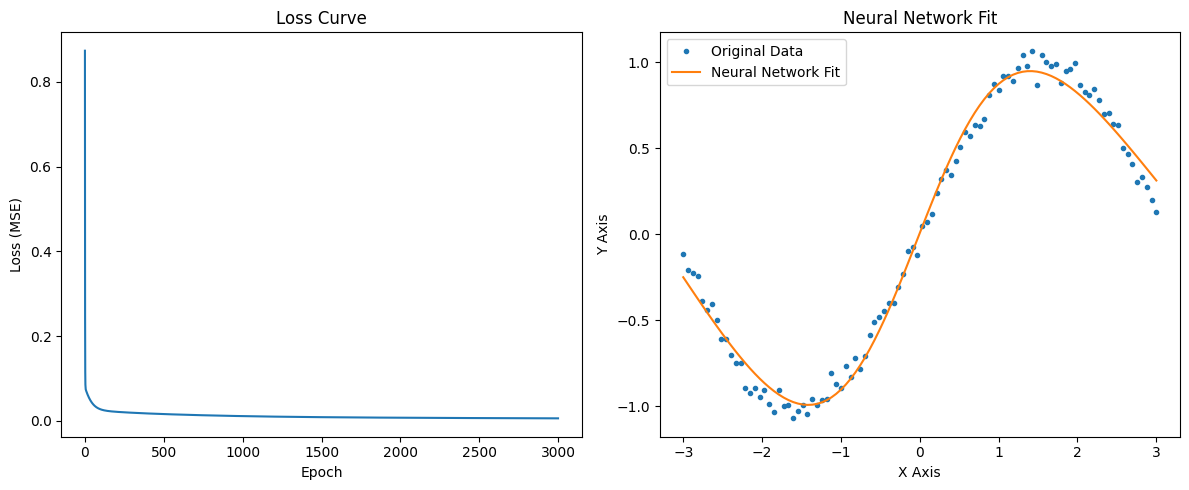

In [3]:
# TODO: Initialise parameters

# Small random values (e.g. np.random.randn(...) * 0.5)
W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8,) * 0.5
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1,) * 0.5


x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

losses = []
# TODO: Forward pass (keep the intermediate values — you need them for backprop):
z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
h  = np.tanh(z1)        # activation
y_hat = h @ W2 + b2     # output, shape (100, 1)
loss  = np.mean((y_hat - y) ** 2)

# TODO: Backward pass (the chain rule, layer by layer):
d_yhat = 2 * (y_hat - y) / len(y)
dW2 = h.T @ d_yhat
db2 = d_yhat.sum(axis=0)
dh  = d_yhat @ W2.T
dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
dW1 = x.T @ dz1
db1 = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,

W1 -= lr * dW1
b1 -= lr * db1
W2 -= lr * dW2
b2 -= lr * db2


for epoch in range(3000):
    # Forward pass
    z1 = x @ W1 + b1
    h  = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss  = np.mean((y_hat - y) ** 2)
    losses.append(loss)   #   record the loss.

    # Backward pass (the chain rule, layer by layer)
    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh  = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    # Update all parameters with learning rate
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2



# Plot the loss curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")

# Plot the final fit over the data
plt.subplot(1, 2, 2)
plt.plot(x, y, '.', label="Original Data")
plt.plot(x, y_hat, '-', label="Neural Network Fit")
plt.title("Neural Network Fit")
plt.xlabel("X Axis")
plt.ylabel("Y Axis")
plt.legend()
plt.tight_layout()
plt.show()



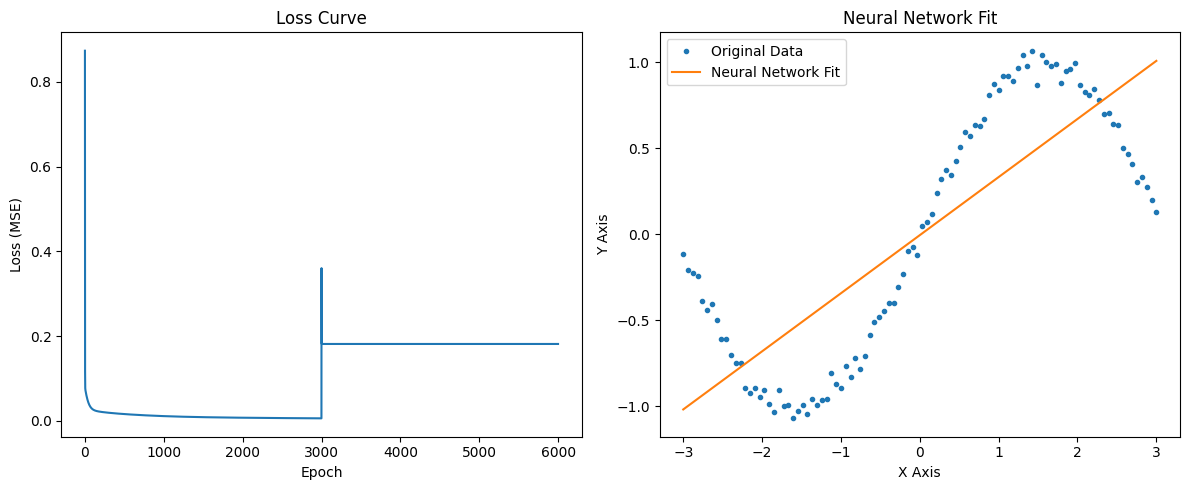

In [4]:

W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8,) * 0.5
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1,) * 0.5


x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
for epoch in range(3000):
    # Forward pass
    z1 = x @ W1 + b1
    h  = z1
    y_hat = h @ W2 + b2
    loss  = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    # Backward pass (the chain rule, layer by layer)
    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh  = d_yhat @ W2.T
    dz1 = dh * 1
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    # Update all parameters with learning rate
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2



# Plot the loss curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")

# Plot the final fit over the data
plt.subplot(1, 2, 2)
plt.plot(x, y, '.', label="Original Data")
plt.plot(x, y_hat, '-', label="Neural Network Fit")
plt.title("Neural Network Fit")
plt.xlabel("X Axis")
plt.ylabel("Y Axis")
plt.legend()
plt.tight_layout()
plt.show()


 1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1. Explain mathematically why a stack of linear layers collapses into one linear layer.
 A linear function of a linear function is still linear. No matter how many layers, the network would be equivalent to a single linear regression model.
 Without the non linear activation the network can't bend and represent curves that are in real data.


 2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few columns of h against x.)
The 8 neurons in the hidden layer detect certain aspects of the data that would help draw out a line to fit the curve. Each layer trys to learn something different from the data to add on to what previous layers have passed on.



 3. This is exactly what loss.backward() will automate in Section 2. In one sentence, what is backpropagation?
 Back propagation is the model trying to adjust its randomly assigned weights to reduce loss and optimise predictions.